# US Accidents (2016 - 2023) - Exploratory Data Analysis

#Data Source - Kaggle
#it contains information about Accidents
#it will help to prevent Accidents

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("US_Accidents_March23.csv")
print(df.head())

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

#Data preparation & Cleaning

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

In [6]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'],format="mixed")

In [7]:
df['End_Time'] = pd.to_datetime(df['End_Time'],format="mixed")

In [7]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [8]:
#how many numeric columns are there in the dataset

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numeric_df = df.select_dtypes(include=numerics)
len(numeric_df.columns)

13

In [9]:
missing_count = df.isnull().sum().sort_values(ascending=False)
print(missing_count)

End_Lng                  3402762
End_Lat                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Sunrise_Sunset             23246
Civil_Twilight             23246
Astronomical_Twilight      23246
Nautical_Twilight          23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
ID                             0
Distance(mi)                   0
Start_Lng                      0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
County    

In [10]:
missing_percentage =(missing_count / len(df)) * 100
print(missing_percentage.round(2))

End_Lng                  44.03
End_Lat                  44.03
Precipitation(in)        28.51
Wind_Chill(F)            25.87
Wind_Speed(mph)           7.39
Visibility(mi)            2.29
Wind_Direction            2.27
Humidity(%)               2.25
Weather_Condition         2.24
Temperature(F)            2.12
Pressure(in)              1.82
Weather_Timestamp         1.56
Sunrise_Sunset            0.30
Civil_Twilight            0.30
Astronomical_Twilight     0.30
Nautical_Twilight         0.30
Airport_Code              0.29
Street                    0.14
Timezone                  0.10
Zipcode                   0.02
City                      0.00
Description               0.00
ID                        0.00
Distance(mi)              0.00
Start_Lng                 0.00
Source                    0.00
Severity                  0.00
Start_Time                0.00
End_Time                  0.00
Start_Lat                 0.00
County                    0.00
Amenity                   0.00
Country 

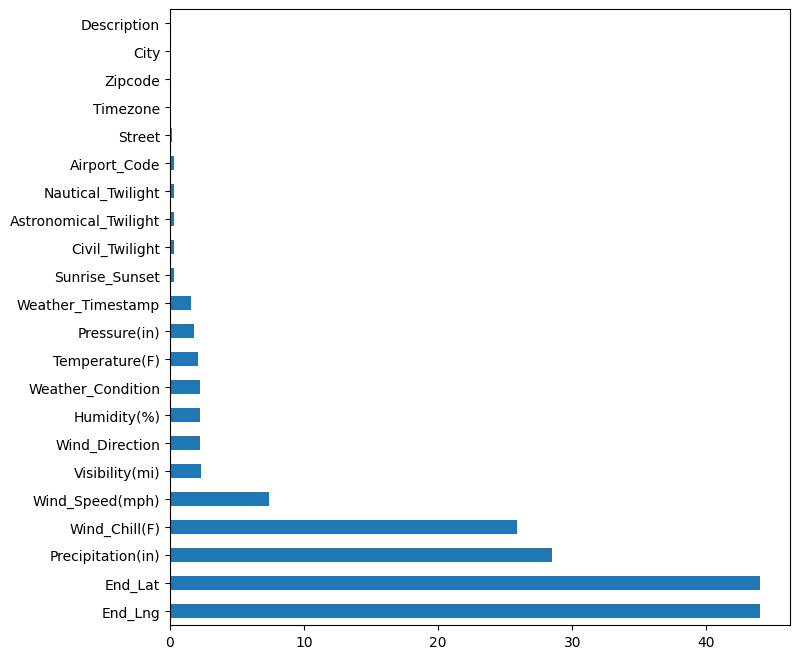

In [11]:
missing_percentage[missing_percentage > 0].plot(kind='barh', figsize=(8,8))
plt.show()

In [8]:
df.drop(columns =
         ["Wind_Chill(F)","Precipitation(in)", "End_Lat", "End_Lng"], inplace=True)

In [9]:
df["Wind_Speed(mph)"] =df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].mean())

In [27]:
print(df.isnull().sum().sort_values(ascending=False))

Visibility(mi)           177098
Wind_Direction           175206
Humidity(%)              174144
Weather_Condition        173459
Temperature(F)           163853
Pressure(in)             140679
Weather_Timestamp        120228
Sunrise_Sunset            23246
Nautical_Twilight         23246
Astronomical_Twilight     23246
Civil_Twilight            23246
Airport_Code              22635
Street                    10869
Timezone                   7808
Zipcode                    1915
City                        253
Description                   5
Source                        0
Start_Lng                     0
Distance(mi)                  0
End_Time                      0
Start_Lat                     0
Start_Time                    0
Severity                      0
ID                            0
County                        0
Amenity                       0
Wind_Speed(mph)               0
State                         0
Country                       0
Bump                          0
Crossing

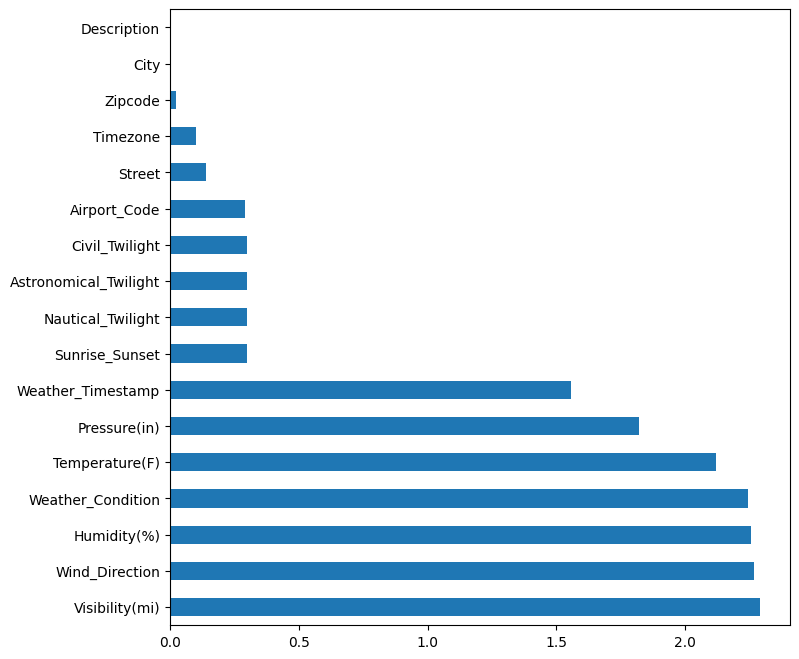

In [29]:
missing_count1 = df.isnull().sum().sort_values(ascending=False)
missing_percentage1 =(missing_count1 / len(df)) * 100
missing_percentage1[missing_percentage1 > 0].plot(kind='barh', figsize=(8,8))
plt.show()

In [10]:
df["Visibility(mi)"] =df["Visibility(mi)"].fillna(df["Visibility(mi)"].mean())
df["Wind_Direction"] =df["Wind_Direction"].ffill()
df["Humidity(%)"] =df["Humidity(%)"].fillna(df["Humidity(%)"].mean())
df["Weather_Condition"] =df["Weather_Condition"].ffill()
df["Temperature(F)"] =df["Temperature(F)"].fillna(df["Temperature(F)"].mean())
df["Pressure(in)"] =df["Pressure(in)"].fillna(df["Pressure(in)"].mean())
df["Weather_Timestamp"] =df["Weather_Timestamp"].ffill()

In [12]:
df['Weather_Condition'].dtypes
df['Wind_Direction'].dtypes
df['Pressure(in)'].dtypes
df['Weather_Timestamp'].dtypes

<StringDtype(storage='python', na_value=nan)>

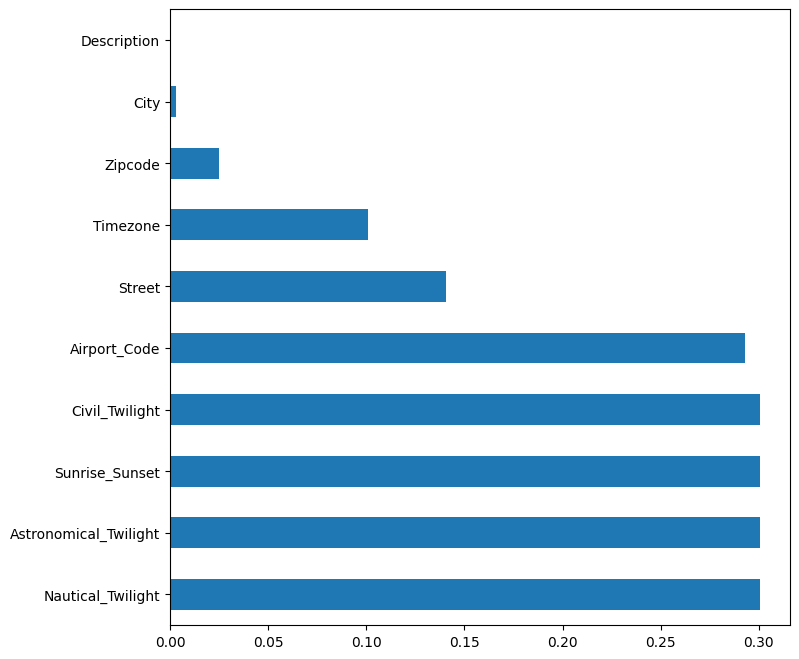

In [40]:
missing_count2 = df.isnull().sum().sort_values(ascending=False)
missing_percentage2 =(missing_count2 / len(df)) * 100
missing_percentage2[missing_percentage2 > 0].plot(kind='barh', figsize=(8,8))
plt.show()

In [13]:
df["Nautical_Twilight"] =df["Nautical_Twilight"].ffill()
df["Astronomical_Twilight"] =df["Astronomical_Twilight"].ffill()
df["Sunrise_Sunset"] =df["Sunrise_Sunset"].ffill()
df["Civil_Twilight"] =df["Civil_Twilight"].ffill()


In [44]:
df['Astronomical_Twilight'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [50]:
print(df['Sunrise_Sunset'])

0          Night
1          Night
2          Night
3          Night
4            Day
           ...  
7728389      Day
7728390      Day
7728391      Day
7728392      Day
7728393      Day
Name: Sunrise_Sunset, Length: 7728394, dtype: str


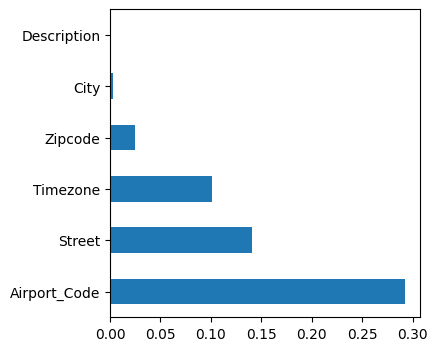

In [53]:
missing_count3 = df.isnull().sum().sort_values(ascending=False)
missing_percentage3 =(missing_count3 / len(df)) * 100
missing_percentage3[missing_percentage3 > 0].plot(kind='barh', figsize=(4,4))
plt.show()

In [ ]:
print(df['City'])

0          US/Eastern
1          US/Eastern
2          US/Eastern
3          US/Eastern
4          US/Eastern
              ...    
7728389    US/Pacific
7728390    US/Pacific
7728391    US/Pacific
7728392    US/Pacific
7728393    US/Pacific
Name: Timezone, Length: 7728394, dtype: str


In [14]:
df["Airport_Code"] =df["Airport_Code"].fillna('Unknown')
df["Street"] =df["Street"].fillna('Unknown')
df["Timezone"] =df["Timezone"].fillna('Unknown')
df["Zipcode"] =df["Zipcode"].fillna('Unknown')
df["City"] =df["City"].ffill()
df.drop(columns = ["Description"], inplace=True)

In [15]:
missing_count_final = df.isnull().sum().sort_values(ascending=False)
missing_percentage_final =(missing_count_final / len(df)) * 100
print(missing_percentage_final)
#missing_percentage_final[missing_percentage_final > 0].plot(kind='barh', figsize=(4,4))
#plt.show()

ID                       0.0
Source                   0.0
Severity                 0.0
Start_Time               0.0
End_Time                 0.0
Start_Lat                0.0
Start_Lng                0.0
Distance(mi)             0.0
Street                   0.0
City                     0.0
County                   0.0
State                    0.0
Zipcode                  0.0
Country                  0.0
Timezone                 0.0
Airport_Code             0.0
Weather_Timestamp        0.0
Temperature(F)           0.0
Humidity(%)              0.0
Pressure(in)             0.0
Visibility(mi)           0.0
Wind_Direction           0.0
Wind_Speed(mph)          0.0
Weather_Condition        0.0
Amenity                  0.0
Bump                     0.0
Crossing                 0.0
Give_Way                 0.0
Junction                 0.0
No_Exit                  0.0
Railway                  0.0
Roundabout               0.0
Station                  0.0
Stop                     0.0
Traffic_Calmin

Now Data is Clean ✔️

# Exploratory Analysis -


In [84]:
df.groupby('City')['ID'].count().sort_values(ascending=False).head(20)


City
Miami            186923
Houston          169612
Los Angeles      156496
Charlotte        138654
Dallas           130940
Orlando          109742
Austin            97361
Raleigh           86080
Nashville         72932
Baton Rouge       71588
Atlanta           68188
Sacramento        66264
San Diego         55505
Phoenix           53974
Minneapolis       51488
Richmond          48847
Oklahoma City     46092
Jacksonville      42450
Tucson            39304
Columbia          38178
Name: ID, dtype: int64

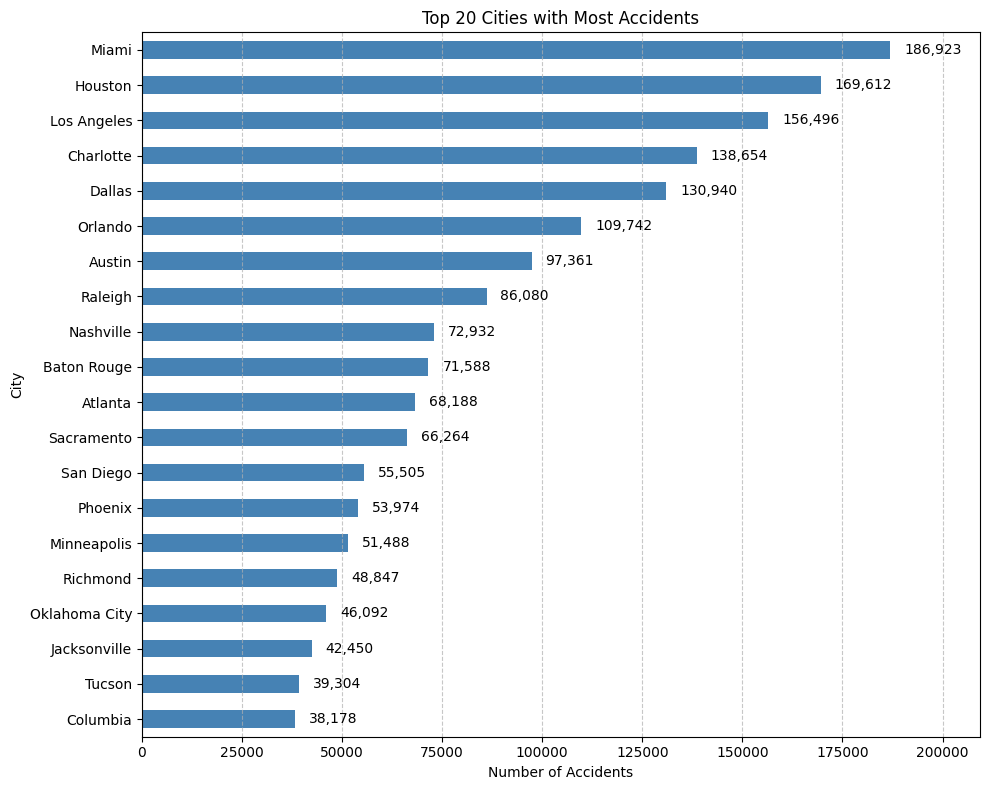

In [ ]:
city_counts = (
    df.groupby("City")["ID"]
      .count()
      .nlargest(20)
      .sort_values()
)

ax = city_counts.plot(
    kind="barh",
    figsize=(10, 8),
    color="steelblue"
)

# Show values on bars
ax.bar_label(
    ax.containers[0],
    labels=[f"{value:,.0f}" for value in city_counts],
    padding=3
)

plt.title("Top 20 Cities with Most Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("City")

# Create extra space for labels
plt.xlim(0, city_counts.max() * 1.12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df['Country'].nunique()                       # only 1 country is present in the dataset which is United States of America

1

Which accident severity is most common?

In [97]:
df['Severity'].value_counts()

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

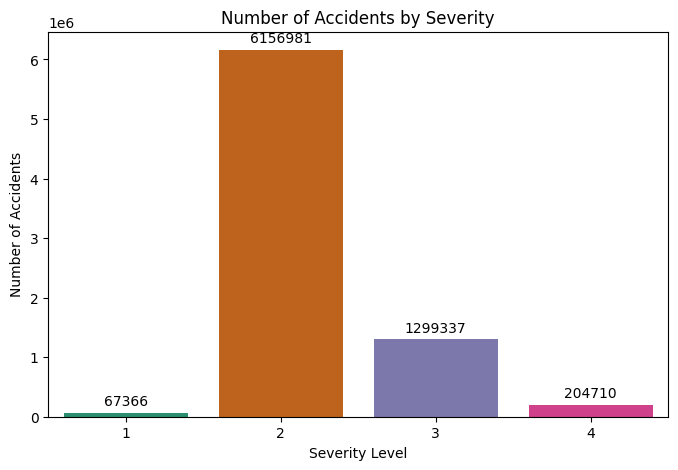

In [104]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Severity",
    order=sorted(df["Severity"].dropna().unique()),
    hue="Severity",
    palette="Dark2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Number of Accidents by Severity")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.show()

When do accidents happen?

In [ ]:
df["Year"]=df['Start_Time'].dt.year
df["Months"] = df["Start_Time"].dt.month_name()
df["Day"]=df['Start_Time'].dt.day_of_week
df["Hour"]=df['Start_Time'].dt.hour



In [17]:
# Convert day number to day name
day_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df["Day_Name"] = df["Day"].map(day_map)

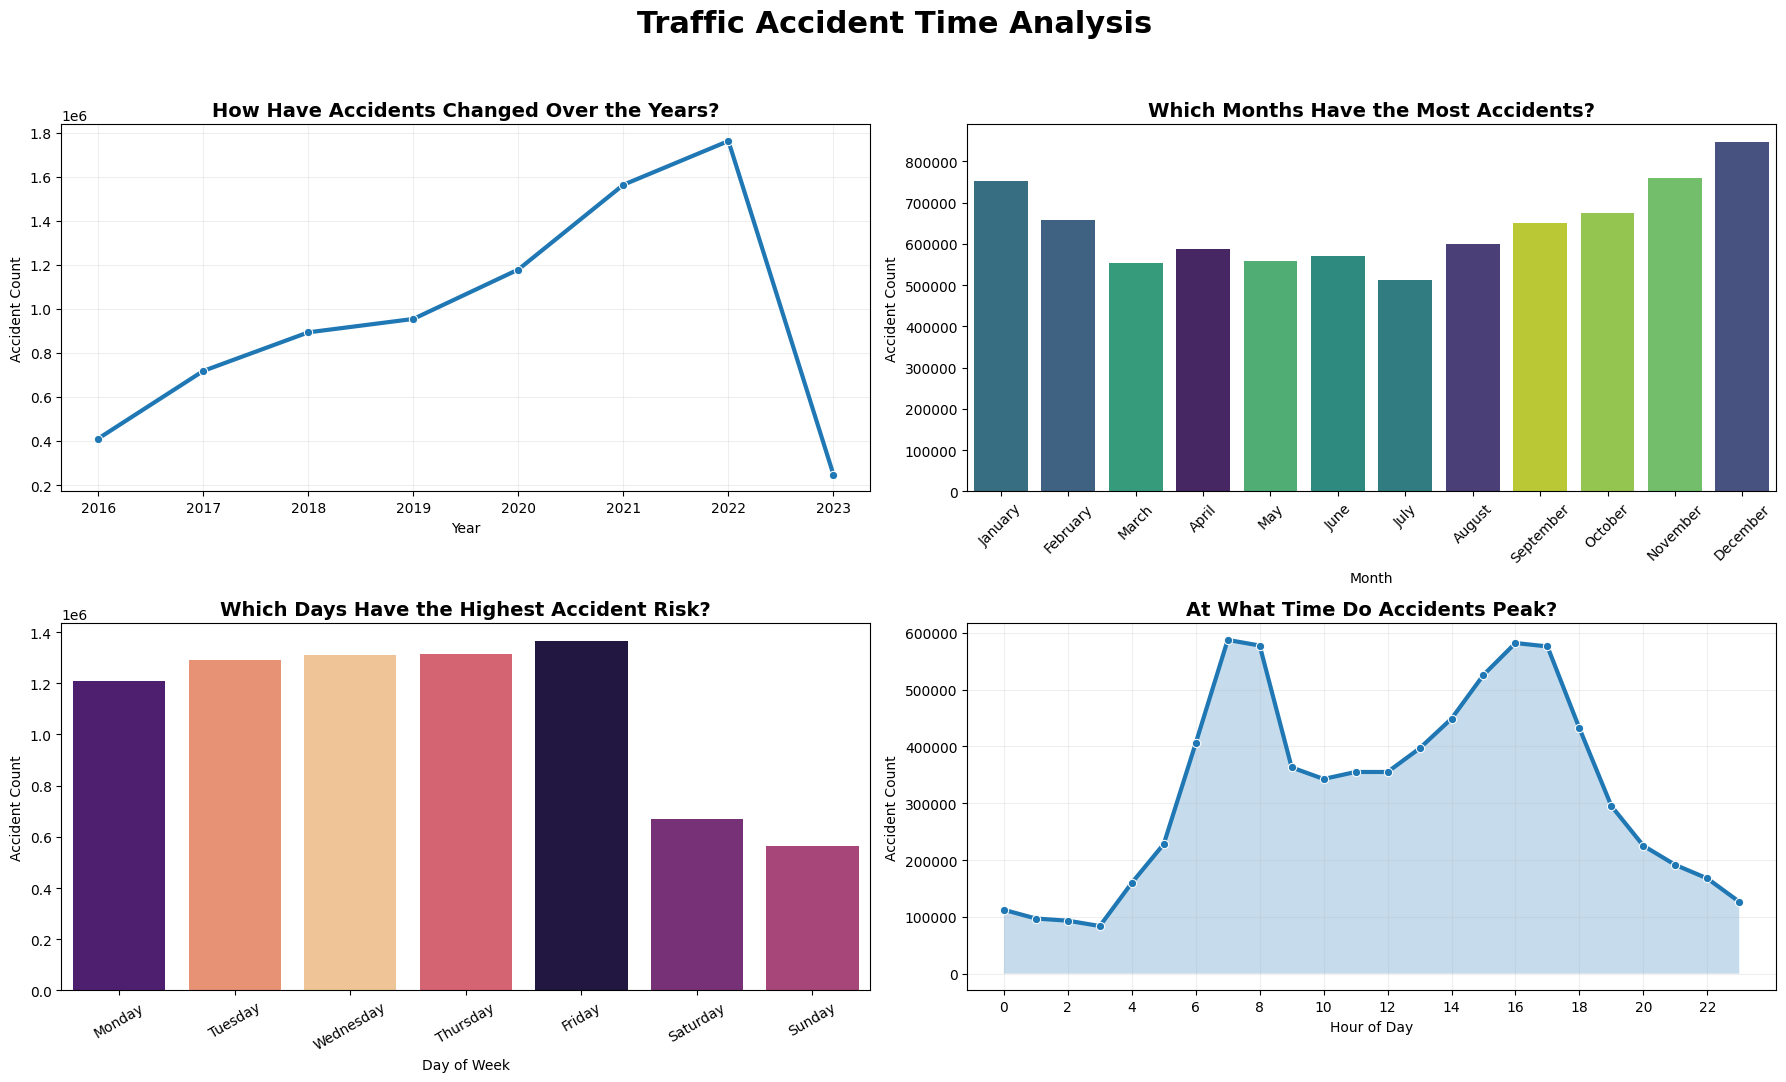

In [ ]:
# ============================================================
# TEMPORAL ANALYSIS OF TRAFFIC ACCIDENTS
# ============================================================
# This section analyzes accident patterns across different
# time dimensions to identify long-term trends, seasonality,
# weekly patterns, and peak accident hours.
#
# Analysis includes:
# 1. Year-wise accident trend
# 2. Month-wise accident distribution
# 3. Day-of-week accident pattern
# 4. Hourly accident pattern
#
# The 'ID' column is used to calculate the total number of
# accidents, as each unique ID represents an accident record.
# ============================================================




# Accident count by Year
year_data = (
    df.groupby("Year")["ID"]
      .count()
      .reset_index(name="Accident_Count")
)


# Accident count by Month
month_data = (
    df.groupby("Months")["ID"]
      .count()
      .reset_index(name="Accident_Count")
)


# Accident count by Day
day_data = (
    df.groupby("Day_Name")["ID"]
      .count()
      .reset_index(name="Accident_Count")
)


# Accident count by Hour
hour_data = (
    df.groupby("Hour")["ID"]
      .count()
      .reset_index(name="Accident_Count")
)


month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]




fig, axes = plt.subplots(2, 2, figsize=(18, 11))

fig.suptitle(
    "Traffic Accident Time Analysis",
    fontsize=22,
    fontweight="bold"
)


# -----------------------------
# 1. Analyze the yearly trend in total traffic accidents
# -----------------------------

sns.lineplot(
    data=year_data,
    x="Year",
    y="Accident_Count",
    marker="o",
    linewidth=3,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "How Have Accidents Changed Over the Years?",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Accident Count")
axes[0, 0].grid(alpha=0.2)


# -----------------------------
# 2. Analyze monthly accident patterns to identify seasonality
# -----------------------------

sns.barplot(
    data=month_data,
    x="Months",
    y="Accident_Count",
    order=month_order,
    hue="Months",
    palette="viridis",
    legend=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Which Months Have the Most Accidents?",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Accident Count")

axes[0, 1].tick_params(
    axis="x",
    rotation=45
)


# -----------------------------
# 3. Analyze accident frequency across different days of the week
# -----------------------------

sns.barplot(
    data=day_data,
    x="Day_Name",
    y="Accident_Count",
    order=day_order,
    hue="Day_Name",
    palette="magma",
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Which Days Have the Highest Accident Risk?",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Day of Week")
axes[1, 0].set_ylabel("Accident Count")

axes[1, 0].tick_params(
    axis="x",
    rotation=30
)


# -----------------------------
# 4. Analyze hourly accident patterns to identify peak accident times
# -----------------------------

sns.lineplot(
    data=hour_data,
    x="Hour",
    y="Accident_Count",
    marker="o",
    linewidth=3,
    ax=axes[1, 1]
)

axes[1, 1].fill_between(
    hour_data["Hour"],
    hour_data["Accident_Count"],
    alpha=0.25
)

axes[1, 1].set_title(
    "At What Time Do Accidents Peak?",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("Accident Count")

axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].grid(alpha=0.2)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

What weather conditions are associated with accidents?

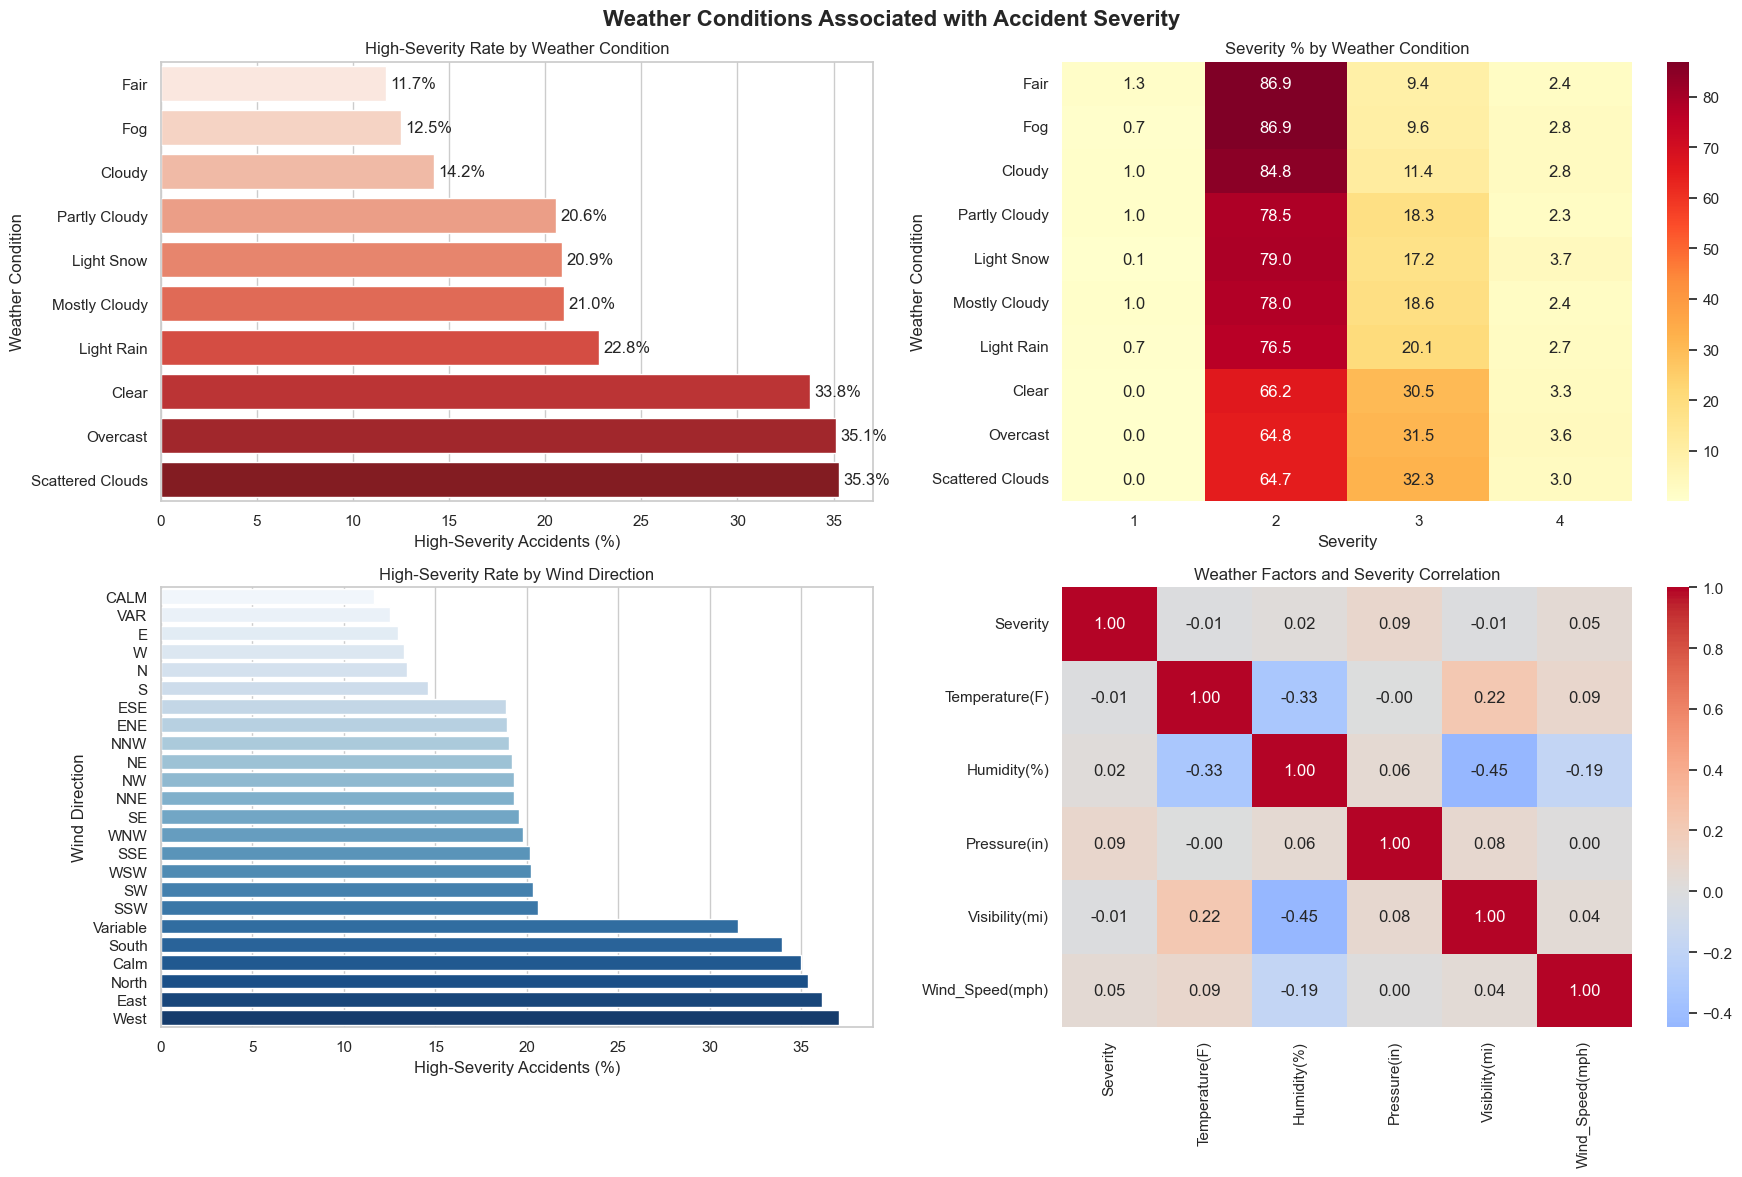

In [26]:

sns.set_theme(style="whitegrid")

# Select weather columns + Severity
weather_cols = [
    "Severity", "Temperature(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Direction", "Wind_Speed(mph)",
    "Weather_Condition"
]

weather_df = df[weather_cols].copy()

# Convert numerical columns to numeric type
num_cols = [
    "Severity", "Temperature(F)", "Humidity(%)",
    "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)"
]

for col in num_cols:
    weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

# Remove rows without Severity
weather_df = weather_df.dropna(subset=["Severity"])

# Replace missing category values
weather_df["Weather_Condition"] = weather_df["Weather_Condition"].fillna("Unknown")
weather_df["Wind_Direction"] = weather_df["Wind_Direction"].fillna("Unknown")

# Severity 3 and 4 = high-severity accident
weather_df["High_Severity"] = weather_df["Severity"].isin([3, 4])

# Weather condition summary
weather_summary = (
    weather_df
    .groupby("Weather_Condition")
    .agg(
        Accident_Count=("Severity", "count"),
        High_Severity_Rate=("High_Severity", "mean")
    )
)

# Convert rate to percentage
weather_summary["High_Severity_Rate"] *= 100

# Keep weather conditions having at least 1,000 accidents
weather_summary = weather_summary[
    weather_summary["Accident_Count"] >= 1000
]

# Top 10 weather conditions by accident count
top_conditions = (
    weather_summary
    .nlargest(10, "Accident_Count")
    .sort_values("High_Severity_Rate")
)


# Create 4 charts together
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Weather Conditions Associated with Accident Severity",
    fontsize=16,
    fontweight="bold"
)

# 1. Severe accident rate by weather condition
sns.barplot(
    data=top_conditions.reset_index(),
    x="High_Severity_Rate",
    y="Weather_Condition",
    hue="Weather_Condition",
    palette="Reds",
    legend=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("High-Severity Rate by Weather Condition")
axes[0, 0].set_xlabel("High-Severity Accidents (%)")
axes[0, 0].set_ylabel("Weather Condition")

for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%.1f%%", padding=3)


# 2. Severity percentage by weather condition
top_names = top_conditions.index.tolist()

severity_mix = pd.crosstab(
    weather_df.loc[
        weather_df["Weather_Condition"].isin(top_names),
        "Weather_Condition"
    ],
    weather_df.loc[
        weather_df["Weather_Condition"].isin(top_names),
        "Severity"
    ],
    normalize="index"
) * 100

severity_mix = severity_mix.reindex(columns=[1, 2, 3, 4], fill_value=0)
severity_mix = severity_mix.reindex(top_names)

sns.heatmap(
    severity_mix,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Severity % by Weather Condition")
axes[0, 1].set_xlabel("Severity")
axes[0, 1].set_ylabel("Weather Condition")


# 3. Severe accident rate by wind direction
wind_summary = (
    weather_df
    .groupby("Wind_Direction")
    .agg(
        Accident_Count=("Severity", "count"),
        High_Severity_Rate=("High_Severity", "mean")
    )
)

wind_summary["High_Severity_Rate"] *= 100

wind_summary = wind_summary[
    wind_summary["Accident_Count"] >= 1000
].sort_values("High_Severity_Rate")

sns.barplot(
    data=wind_summary.reset_index(),
    x="High_Severity_Rate",
    y="Wind_Direction",
    hue="Wind_Direction",
    palette="Blues",
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("High-Severity Rate by Wind Direction")
axes[1, 0].set_xlabel("High-Severity Accidents (%)")
axes[1, 0].set_ylabel("Wind Direction")


# 4. Correlation of weather columns with Severity
corr_cols = [
    "Severity", "Temperature(F)", "Humidity(%)",
    "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)"
]

corr_df = weather_df[corr_cols].dropna()

# Use sample for faster result on a large dataset
corr_df = corr_df.sample(
    n=min(200_000, len(corr_df)),
    random_state=42
)

corr_matrix = corr_df.corr(method="spearman")

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Weather Factors and Severity Correlation")

plt.tight_layout()
plt.show()

Which road features are present during accidents?

,Road_Feature,Accident_Count,Feature_Present_%,Average_Severity,High_Severity_Rate
11,Traffic Signal,1143772,14.80,2.09,9.51
2,Crossing,873763,11.31,2.06,7.04
4,Junction,571342,7.39,2.30,26.79
9,Stop,214371,2.77,2.08,6.22
8,Station,201901,2.61,2.08,7.51
0,Amenity,96334,1.25,2.07,6.29
6,Railway,66979,0.87,2.16,15.13
3,Give Way,36582,0.47,2.18,16.16
5,No Exit,19545,0.25,2.11,11.28
10,Traffic Calming,7598,0.10,2.13,12.52


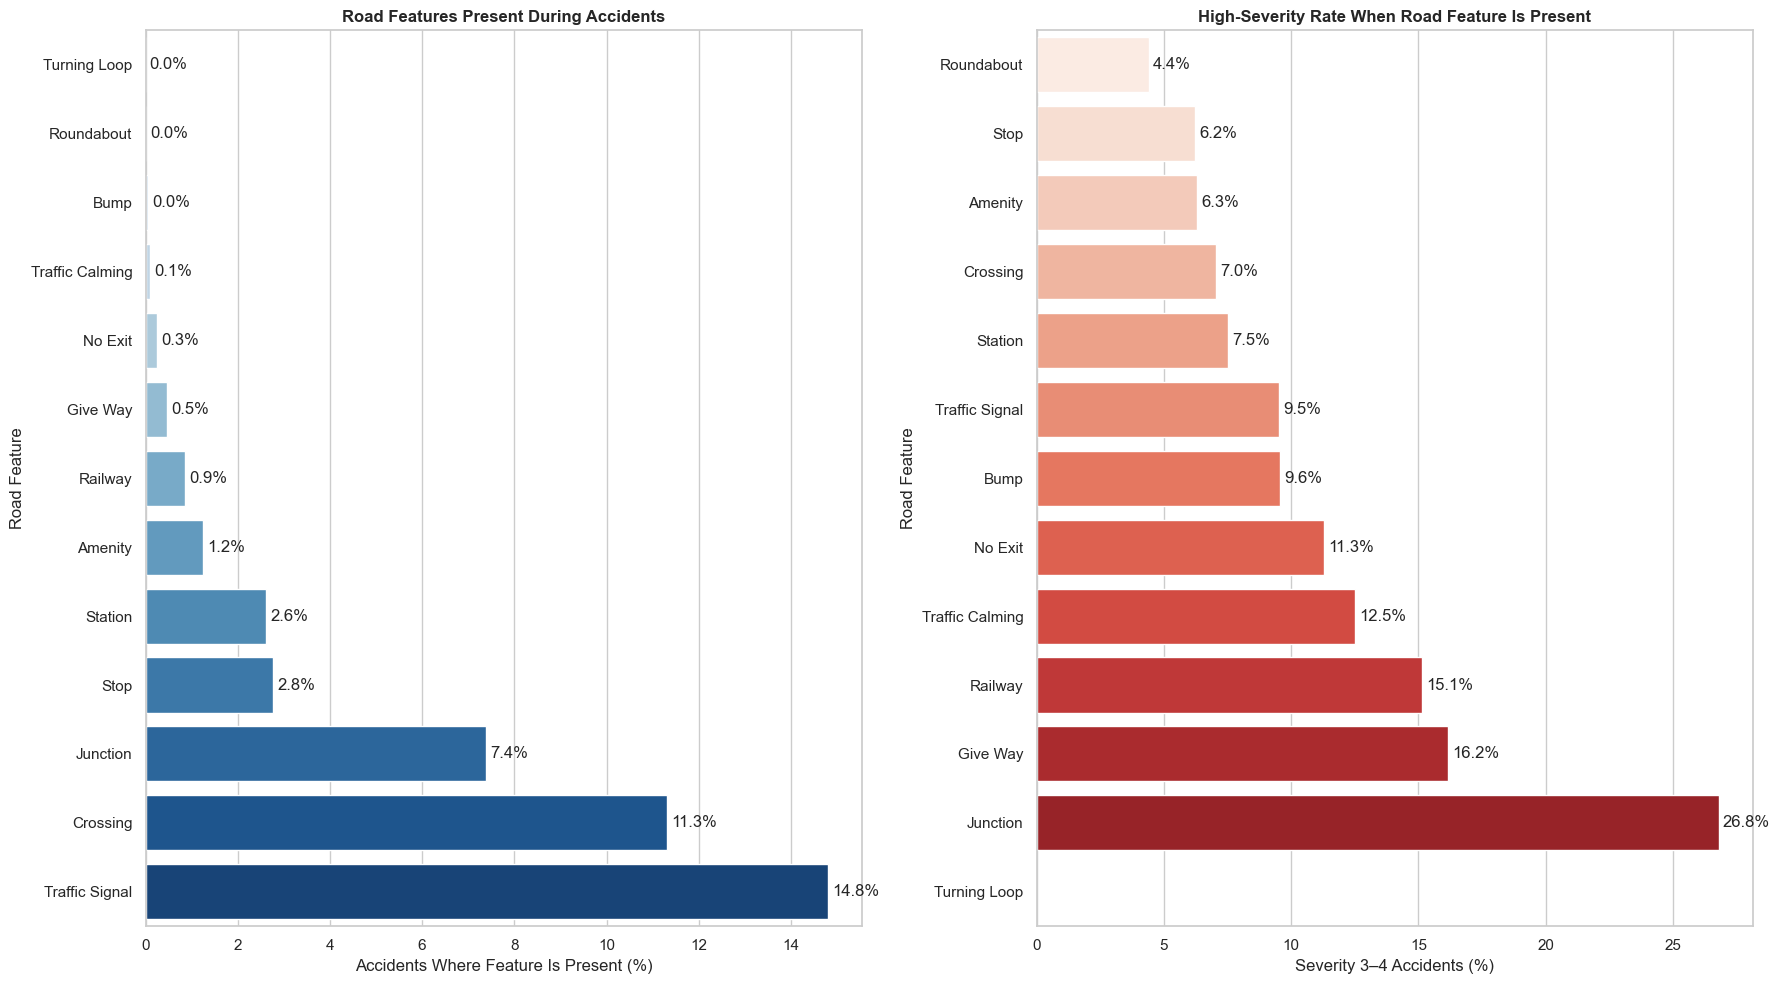

In [30]:
# ==========================================================
# ROAD FEATURE ANALYSIS
# ==========================================================
# Goal:
# Find which road features are present during accidents.
#
# Examples of road features:
# Traffic Signal, Junction, Crossing, Railway, Stop, Bump.
#
# We also check which features have more high-severity accidents.
# High Severity means Severity 3 or 4.
# ==========================================================

sns.set_theme(style="whitegrid")

# Road feature columns
road_features = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]

# Keep Severity and road-feature columns
road_df = df[["Severity"] + road_features].copy()

# Keep rows where Severity is available
road_df = road_df.dropna(subset=["Severity"])

# Severity 3 and 4 = high-severity accident
road_df["High_Severity"] = road_df["Severity"].isin([3, 4])

# Convert True/False values safely
for col in road_features:
    road_df[col] = (
        road_df[col]
        .astype("string")
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False
        })
    )

# Create summary for every road feature
summary_list = []

for feature in road_features:

    # Keep accidents where this feature is present
    feature_df = road_df[road_df[feature] == True]

    summary_list.append({
        "Road_Feature": feature,
        "Accident_Count": len(feature_df),
        "Feature_Present_%": len(feature_df) / len(road_df) * 100,
        "Average_Severity": feature_df["Severity"].mean(),
        "High_Severity_Rate": feature_df["High_Severity"].mean() * 100
    })

feature_summary = pd.DataFrame(summary_list)

# Clean feature names for visuals
feature_summary["Road_Feature"] = (
    feature_summary["Road_Feature"]
    .str.replace("_", " ")
)

display(
    feature_summary
    .sort_values("Feature_Present_%", ascending=False)
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# -----------------------------------------
# Chart 1: Feature presence during accidents
# -----------------------------------------
feature_presence = feature_summary.sort_values("Feature_Present_%")

sns.barplot(
    data=feature_presence,
    x="Feature_Present_%",
    y="Road_Feature",
    hue="Road_Feature",
    palette="Blues",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Road Features Present During Accidents",
    fontweight="bold"
)
axes[0].set_xlabel("Accidents Where Feature Is Present (%)")
axes[0].set_ylabel("Road Feature")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=3)


# -----------------------------------------
# Chart 2: Severity rate when feature exists
# -----------------------------------------
severity_feature = feature_summary.sort_values("High_Severity_Rate")

sns.barplot(
    data=severity_feature,
    x="High_Severity_Rate",
    y="Road_Feature",
    hue="Road_Feature",
    palette="Reds",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "High-Severity Rate When Road Feature Is Present",
    fontweight="bold"
)
axes[1].set_xlabel("Severity 3–4 Accidents (%)")
axes[1].set_ylabel("Road Feature")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

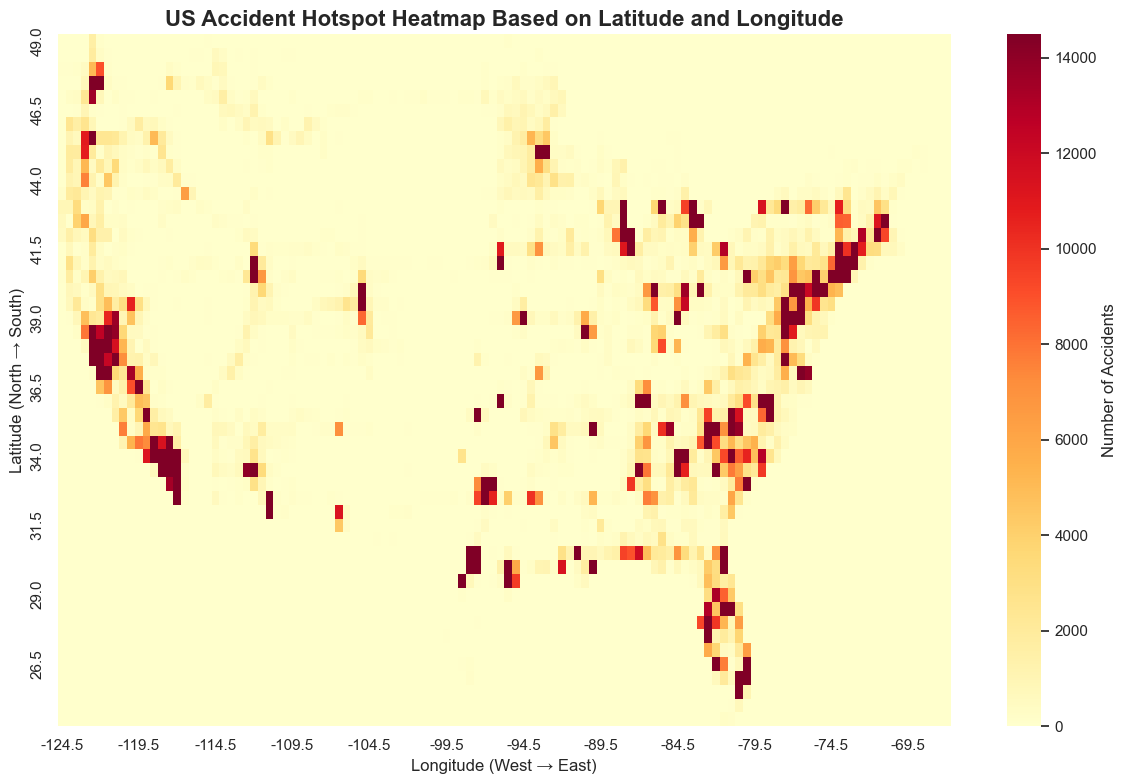

In [36]:

# Keep location columns only
location_df = df[
    ["ID", "Start_Lat", "Start_Lng", "State", "City"]
].copy()

# Remove missing latitude or longitude
location_df = location_df.dropna(
    subset=["Start_Lat", "Start_Lng"]
)

# Keep valid United States coordinates
# This is mainly for the mainland US map
location_df = location_df[
    location_df["Start_Lat"].between(24, 50) &
    location_df["Start_Lng"].between(-125, -66)
]

# Top 15 states with most accidents
top_states = (
    location_df
    .groupby("State")["ID"]
    .nunique()
    .nlargest(15)
    .sort_values()
)

# Top 15 cities with most accidents
top_cities = (
    location_df
    .dropna(subset=["City"])
    .groupby(["City", "State"])["ID"]
    .nunique()
    .nlargest(15)
    .sort_values()
)

grid_size = 0.5

spatial_grid = (
    location_df
    .assign(
        Lat_Bin=(location_df["Start_Lat"] / grid_size).round() * grid_size,
        Lng_Bin=(location_df["Start_Lng"] / grid_size).round() * grid_size
    )
    .groupby(["Lat_Bin", "Lng_Bin"])["ID"]
    .nunique()
    .reset_index(name="Accident_Count")
)

# Convert location groups into heatmap format
heatmap_data = spatial_grid.pivot(
    index="Lat_Bin",
    columns="Lng_Bin",
    values="Accident_Count"
).fillna(0)

# Keep north at the top and south at the bottom
heatmap_data = heatmap_data.sort_index(ascending=False)

# Create accident hotspot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    robust=True,
    cbar_kws={"label": "Number of Accidents"},
    xticklabels=10,
    yticklabels=5
)

plt.title(
    "US Accident Hotspot Heatmap Based on Latitude and Longitude",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Longitude (West → East)")
plt.ylabel("Latitude (North → South)")

plt.tight_layout()
plt.show()

In [37]:


sns.set_theme(style="whitegrid", context="notebook")

# ---------------------------------------------------
# 1. Create State and City accident summaries
# ---------------------------------------------------
area_df = df[["ID", "State", "City"]].dropna(subset=["State"])

# Top 10 states
state_data = (
    area_df
    .groupby("State")["ID"]
    .nunique()
    .reset_index(name="Accident_Count")
    .nlargest(10, "Accident_Count")
)

state_data["Accident_Percentage"] = (
    state_data["Accident_Count"] /
    area_df["ID"].nunique() * 100
)

# Top 10 cities
city_data = (
    area_df
    .dropna(subset=["City"])
    .assign(City_Area=lambda x: x["City"] + ", " + x["State"])
    .groupby("City_Area")["ID"]
    .nunique()
    .reset_index(name="Accident_Count")
    .nlargest(10, "Accident_Count")
)

city_data["Accident_Percentage"] = (
    city_data["Accident_Count"] /
    area_df["ID"].nunique() * 100
)

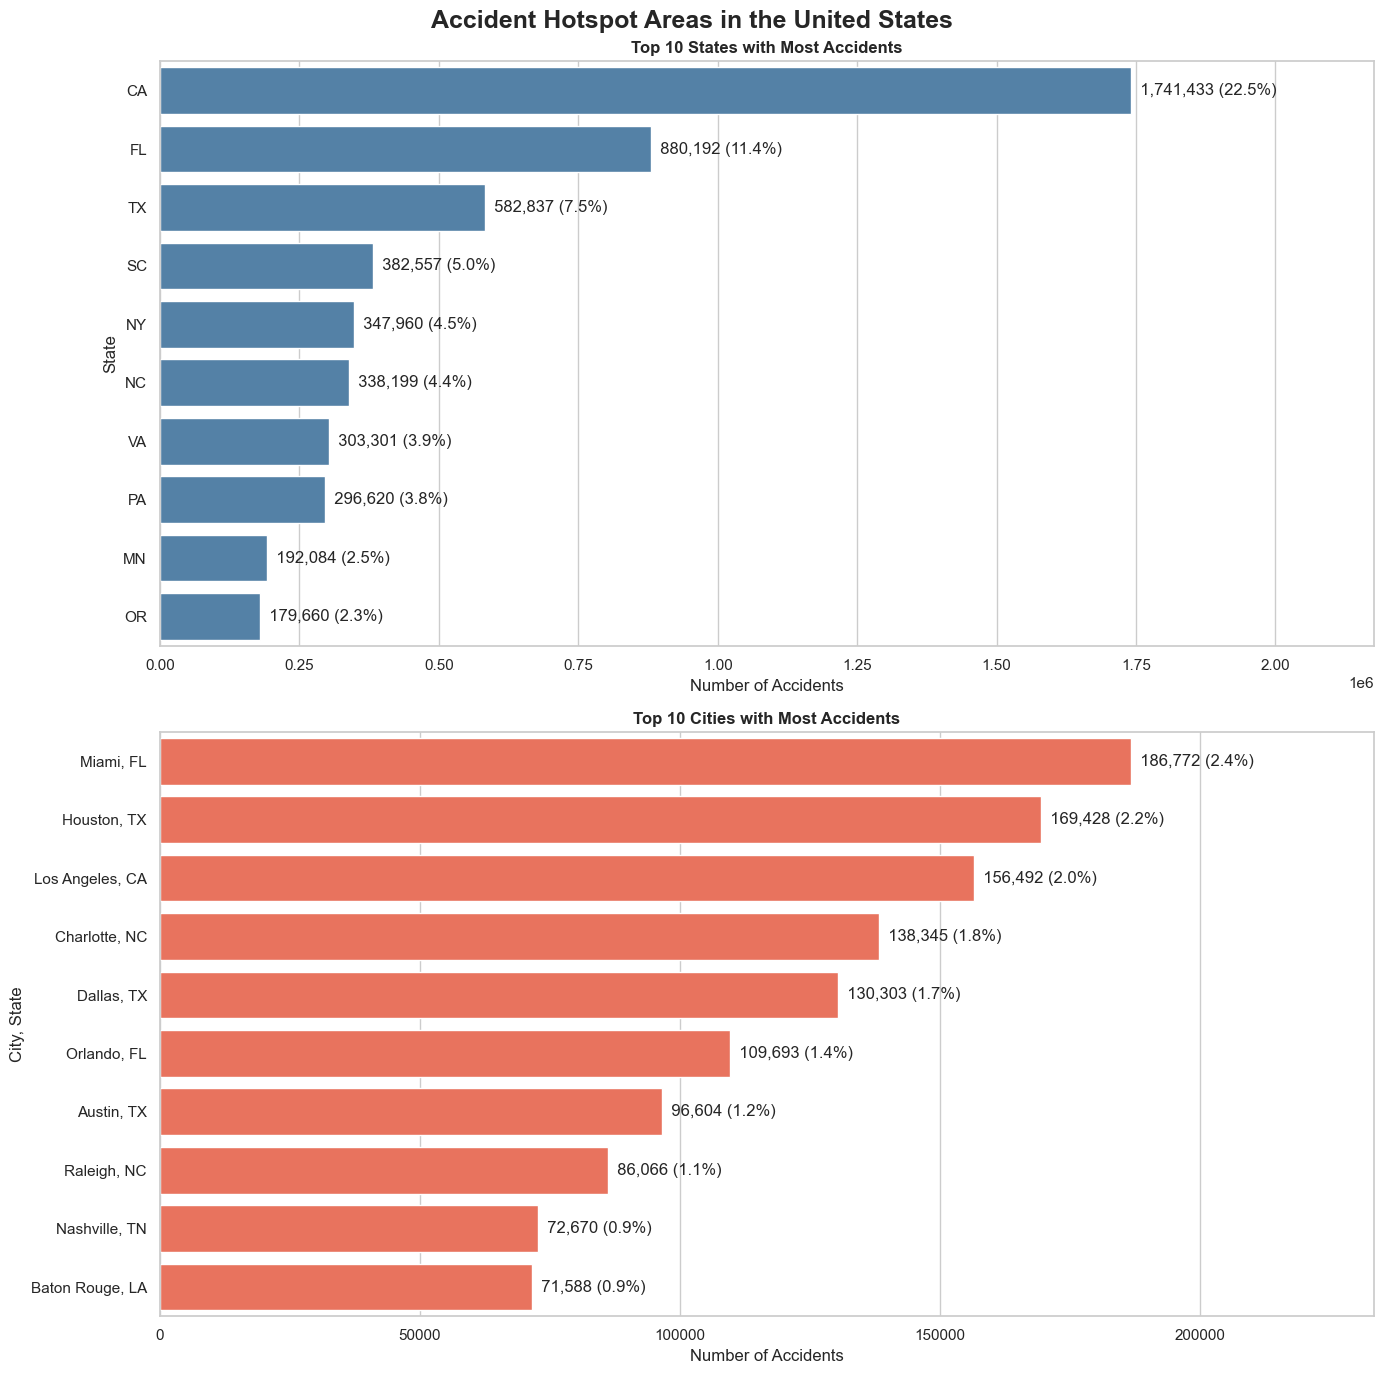

In [38]:
# ---------------------------------------------------
# 2. Create clear visual
# ---------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

fig.suptitle(
    "Accident Hotspot Areas in the United States",
    fontsize=18,
    fontweight="bold"
)

# Top States
sns.barplot(
    data=state_data,
    x="Accident_Count",
    y="State",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Top 10 States with Most Accidents", fontweight="bold")
axes[0].set_xlabel("Number of Accidents")
axes[0].set_ylabel("State")

for i, row in state_data.iterrows():
    axes[0].text(
        row["Accident_Count"],
        list(state_data.index).index(i),
        f'  {row["Accident_Count"]:,.0f} ({row["Accident_Percentage"]:.1f}%)',
        va="center"
    )

axes[0].set_xlim(0, state_data["Accident_Count"].max() * 1.25)


# Top Cities
sns.barplot(
    data=city_data,
    x="Accident_Count",
    y="City_Area",
    color="tomato",
    ax=axes[1]
)

axes[1].set_title("Top 10 Cities with Most Accidents", fontweight="bold")
axes[1].set_xlabel("Number of Accidents")
axes[1].set_ylabel("City, State")

for i, row in city_data.iterrows():
    axes[1].text(
        row["Accident_Count"],
        list(city_data.index).index(i),
        f'  {row["Accident_Count"]:,.0f} ({row["Accident_Percentage"]:.1f}%)',
        va="center"
    )

axes[1].set_xlim(0, city_data["Accident_Count"].max() * 1.25)

plt.tight_layout()
plt.show()

In [39]:
top_state = state_data.iloc[0]
top_city = city_data.iloc[0]

print(
    f"State with most accidents: {top_state['State']} "
    f"({top_state['Accident_Count']:,.0f} accidents)"
)

print(
    f"City with most accidents: {top_city['City_Area']} "
    f"({top_city['Accident_Count']:,.0f} accidents)"
)

State with most accidents: CA (1,741,433 accidents)
City with most accidents: Miami, FL (186,772 accidents)


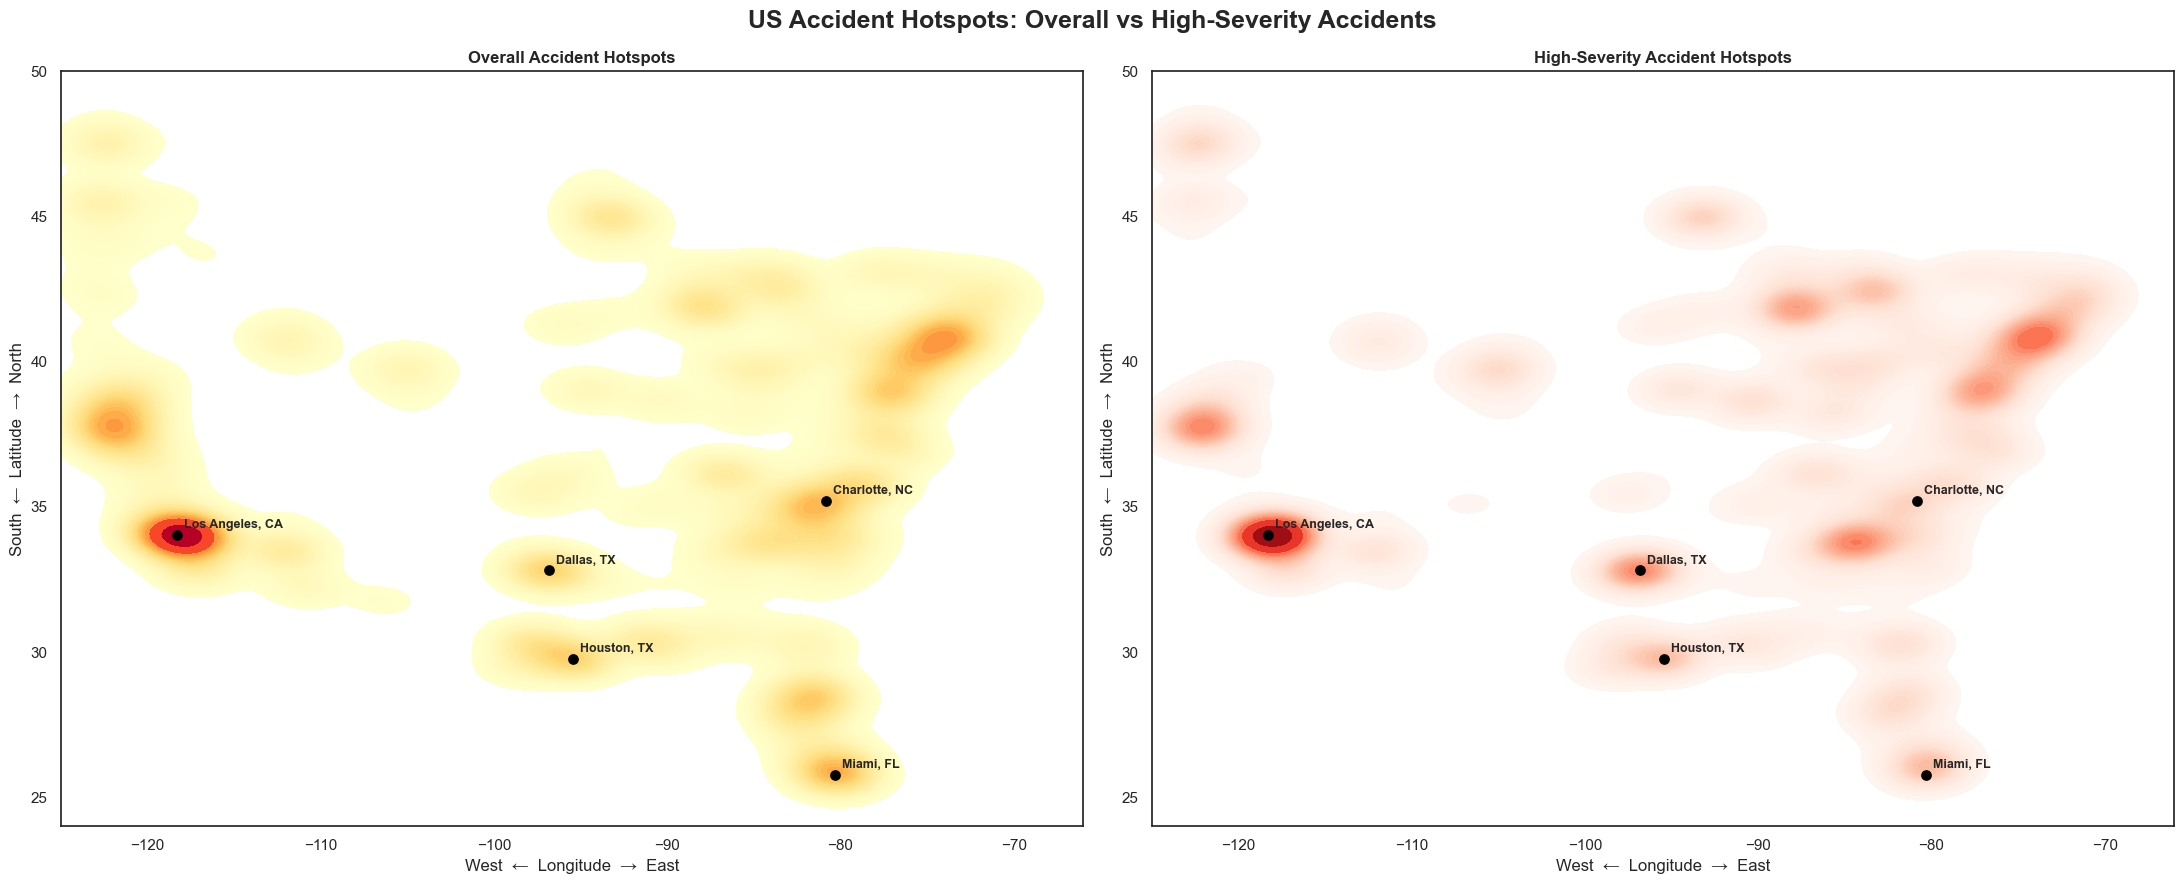

In [41]:


sns.set_theme(style="white")

# Keep location, city, state, and severity columns
map_df = df[
    ["ID", "Start_Lat", "Start_Lng", "Severity", "City", "State"]
].copy()

# Remove missing location and severity values
map_df = map_df.dropna(
    subset=["Start_Lat", "Start_Lng", "Severity"]
)

# Keep mainland US coordinates
map_df = map_df[
    map_df["Start_Lat"].between(24, 50) &
    map_df["Start_Lng"].between(-125, -66)
]

# High Severity = Severity 3 or 4
map_df["High_Severity"] = map_df["Severity"].isin([3, 4])

# Take samples for faster visualization
all_accidents = map_df.sample(
    n=min(100_000, len(map_df)),
    random_state=42
)

severe_accidents = map_df[
    map_df["High_Severity"]
].sample(
    n=min(100_000, map_df["High_Severity"].sum()),
    random_state=42
)

# Find top 5 cities and their average location
top_cities_map = (
    map_df
    .dropna(subset=["City", "State"])
    .groupby(["City", "State"])
    .agg(
        Accident_Count=("ID", "nunique"),
        Latitude=("Start_Lat", "mean"),
        Longitude=("Start_Lng", "mean")
    )
    .reset_index()
    .nlargest(5, "Accident_Count")
)

# Create two hotspot maps together
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

fig.suptitle(
    "US Accident Hotspots: Overall vs High-Severity Accidents",
    fontsize=18,
    fontweight="bold"
)

# --------------------------------------------------
# Map 1: All accident hotspots
# --------------------------------------------------
sns.kdeplot(
    data=all_accidents,
    x="Start_Lng",
    y="Start_Lat",
    fill=True,
    cmap="YlOrRd",
    levels=35,
    thresh=0.05,
    bw_adjust=0.6,
    clip=[(-125, -66), (24, 50)],
    ax=axes[0]
)

axes[0].set_title("Overall Accident Hotspots", fontweight="bold")
axes[0].set_xlabel("West  ←  Longitude  →  East")
axes[0].set_ylabel("South  ←  Latitude  →  North")


# --------------------------------------------------
# Map 2: High-severity accident hotspots
# --------------------------------------------------
sns.kdeplot(
    data=severe_accidents,
    x="Start_Lng",
    y="Start_Lat",
    fill=True,
    cmap="Reds",
    levels=35,
    thresh=0.05,
    bw_adjust=0.6,
    clip=[(-125, -66), (24, 50)],
    ax=axes[1]
)

axes[1].set_title("High-Severity Accident Hotspots", fontweight="bold")
axes[1].set_xlabel("West  ←  Longitude  →  East")
axes[1].set_ylabel("South  ←  Latitude  →  North")


# Add top city labels to both maps
for ax in axes:
    for _, row in top_cities_map.iterrows():

        ax.scatter(
            row["Longitude"],
            row["Latitude"],
            color="black",
            s=45
        )

        ax.annotate(
            f'{row["City"]}, {row["State"]}',
            (row["Longitude"], row["Latitude"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold"
        )

    ax.set_xlim(-125, -66)
    ax.set_ylim(24, 50)

plt.tight_layout()
plt.show()

Clean DATA save for deep analysis and creating Dashboard


In [45]:
df.to_csv("US_Accidents_March23_Cleaned.csv", index=False)